In [3]:
from pgmpy.models import BayesianNetwork

from pgmpy.estimators import HillClimbSearch, BDsScore
from pgmpy.factors.discrete import State
import numpy as np
import pandas as pd

import pdb

import itertools
import pysmile
import pysmile_license

c:\Users\danie\anaconda3\envs\crc_incentives\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
net2 = pysmile.Network()
net2.read_file(f"../models/DM_screening_rel_point_cond_mut_info_linear.xdsl")
net2.clear_all_evidence()

patient_chars = {
"Age": "age_5_old_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_2",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "False",
"Hypertension": "False",
}

for key, value in patient_chars.items():
    net2.set_evidence(key, value)

net2.update_beliefs()

p_crc = net2.get_node_value("CRC")[1]
p_no_crc = net2.get_node_value("CRC")[0]

vars1 = net2.get_outcome_ids("Screening")
arr = np.array(net2.get_node_value("Screening"))
df_scr = pd.DataFrame(arr.reshape(1,-1), index=["Screening"], columns=vars1)

# take column with the highest value
scr = df_scr.idxmax(axis=1).values[0]
scr_decision_patient = ["No_screening", scr]

print(f"Patient decision: {scr_decision_patient}")
print(f"Probability of CRC: {p_crc}")

Patient decision: ['No_screening', 'Stool_DNA']
Probability of CRC: 0.002235155200821302


In [60]:
import numpy as np


u_EQ5D = {
    "age_1_young_adult": 0.966,
    "age_2_young": 0.963,
    "age_3_young_adult": 0.939,
    "age_4_adult": 0.911,
    "age_5_old_adult": 0.884,
}

def EQ5D(age):
    return u_EQ5D[age]


scr_costs_dict = {
    "No_screening": 0,
    "gFOBT": 12.14,
    "FIT": 14.34,
    "Blood_based": 123.13,
    "Stool_DNA": 236.88,
    "CTC": 95.41,
    "CC": 510.24,
    "Colonoscopy": 1000
}

def scr_costs(scr):
    return scr_costs_dict[scr]

sensitivity_dict = {
    "No_screening": 0,
    "gFOBT": 0.45,
    "FIT": 0.75,
    "Blood_based": 0.66,
    "Stool_DNA": 0.923,
    "CTC": 0.8,
    "CC": 0.87,
    "Colonoscopy": 0.97
}

def sensitivity(scr):
    return sensitivity_dict[scr]

specificity_dict = {
    "No_screening": 1,
    "gFOBT": 0.978,
    "FIT": 0.966,
    "Blood_based": 0.91,
    "Stool_DNA": 0.866,
    "CTC": 0.89,
    "CC": 0.92,
    "Colonoscopy": 0.99
}

def specificity(scr):
    return specificity_dict[scr]

comfort_dict = {
    "No_screening": 4,
    "gFOBT": 3,
    "FIT": 3,
    "Blood_based": 3,
    "Stool_DNA": 3,
    "CTC": 2,
    "CC": 2,
    "Colonoscopy": 1
}

def comfort(scr):
    return comfort_dict[scr]


def diff_QALY(crc, r_scr):
    if crc == 1 and r_scr == 1:
        return np.random.uniform(5, 100)
    elif crc == 1 and r_scr == 0:
        return - np.random.uniform(3, 5)
    else:
        return 0 
    

def cost_PM(age, crc, scr, r_scr, K):
    if scr == "No_screening":
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr)
    else:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr) - K - scr_costs(scr) - 25955*crc*r_scr
    
def cost_SP(age, crc, scr, scr_decision, r_scr, K):
    if scr == "No_screening" or scr_decision == 0:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr)
    else:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr) - K - scr_costs(scr) - 25955*crc*r_scr

def cost_cit(age, crc, scr, r_scr, K):
    if scr == "No_screening":
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr)
    else:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr) + K - 100*np.random.normal(1.0/comfort(scr), 1.0) - 1000*r_scr

import pandas as pd
def calculate_marginals_age():
    df_test = pd.read_csv("../models/df_test_new_w_lim.csv", index_col=0)

    dict_marginals = df_test.groupby(["Age"])["CRC"].mean().to_dict()
    return dict_marginals

dict_marginals = calculate_marginals_age()

# Define how much each age group underestimates their risk
age_underestimation_factors = {
    "age_1_young_adult": 0.1,  # Perceives 10% of their actual risk
    "age_2_young": 0.2,        # Perceives 20% of their actual risk
    "age_3_young_adult": 0.3,  # Perceives 30% of their actual risk
    "age_4_adult": 0.5,        # Perceives 50% of their actual risk
    "age_5_old_adult": 0.8     # Perceives 80% of their actual risk
}

def prob_crc_cit(true_p_crc, age):
    base_factor = age_underestimation_factors[age]
    
    # Add a little uniform noise so not everyone in the age group is identical
    factor = base_factor * np.random.uniform(0.8, 1.2)
    factor = min(max(factor, 0.01), 0.99)
    
    r = true_p_crc * factor
    
    if r <= 0:
        return 0
        
    var = (r * 0.1)**2
    
    d1 = ((1-r)/var - 1/r)*r**2
    d2 = d1*(1/r - 1)
    
    if d1 <= 0 or d2 <= 0:
        return r
        
    return np.random.beta(d1, d2)


def utility_func(payoff):
    # E.g., Risk averse utility
    return payoff # 1 - np.exp(-0.0001 * payoff)

### Citizen prob of accepting scr varying K

In [73]:
import matplotlib.pyplot as plt



def plot_histograms_count_distrib(net2, patient_chars):

    for key, value in patient_chars.items():
        net2.set_evidence(key, value)

    net2.update_beliefs()

    p_crc = net2.get_node_value("CRC")[1]
    p_no_crc = net2.get_node_value("CRC")[0]

    vars1 = net2.get_outcome_ids("Screening")
    arr = np.array(net2.get_node_value("Screening"))
    df_scr = pd.DataFrame(arr.reshape(1,-1), index=["Screening"], columns=vars1)

    # take column with the highest value
    scr = df_scr.idxmax(axis=1).values[0]
    scr_decision_patient = ["No_screening", scr]

    print(f"Optimal screening: {scr}")
    print(f"p_crc = {p_crc}")

    # Number of times the *same* citizen evaluates their decision under uncertainty
    total_sim = 1000 
    age = patient_chars["Age"]

    scr_decision_patient = ["No_screening", scr]


    for ind_k, k in enumerate([0, 1, 50, 100, 200]):
        plt_arr = []

        # We calculate the probability of this specific citizen accepting screening
        # by running total_sim monte carlo evaluations of their utility.
        # We loop 100 times just to generate a histogram of that probability to verify stability.
        for _ in range(100):
            s_opt_count = 0
            
            for _ in range(total_sim):
                # 1. The citizen draws their specific bias and belief for this evaluation instance
                p_belief = prob_crc_cit(p_crc, age)
                cit_comfort_noise = 100 * np.random.normal(1.0, 1.0) 

                expected_utilities = np.zeros((len(scr_decision_patient),))
                
                for j_s, scr_ in enumerate(scr_decision_patient):
                    future_utilities = []
                    
                    # 2. Citizen projects 100 possible futures to calculate expected utility
                    for _ in range(100):
                        c_sim = np.random.binomial(1, p_belief)
                        r_sim = np.random.binomial(1, sensitivity(scr_) * c_sim + (1 - specificity(scr_)) * (1 - c_sim))
                        
                        val_QALY = 30968 * EQ5D(age) * diff_QALY(c_sim, r_sim)
                        if scr_ == "No_screening":
                            payoff = val_QALY
                        else:
                            payoff = val_QALY + k - (cit_comfort_noise / comfort(scr_)) - 1000 * r_sim
                            
                        future_utilities.append(utility_func(payoff))
                        
                    expected_utilities[j_s] = np.mean(future_utilities)
                    
                s_opt_count += np.argmax(expected_utilities)

            # Probability this citizen accepts screening at this K
            p_scr = s_opt_count / total_sim
            plt_arr.append(p_scr)
    
        plt_arr = np.array(plt_arr)
        # for each K, plot the distribution of p_scr with a different color
        plt.hist(plt_arr, bins = 16 , alpha=0.5, label=str(k))
        plt.legend(loc='upper right')
        plt.title("Age = " + age)
        print(f"K = {k}, mean_p_scr = {np.mean(plt_arr)}, median_p_scr = {np.median(plt_arr)}")

Optimal screening: Stool_DNA
p_crc = 0.0018651703060249447
K = 0, mean_p_scr = 0.16518, median_p_scr = 0.166
K = 1, mean_p_scr = 0.16380999999999996, median_p_scr = 0.164
K = 50, mean_p_scr = 0.16961, median_p_scr = 0.169
K = 100, mean_p_scr = 0.22927, median_p_scr = 0.229
K = 200, mean_p_scr = 0.79285, median_p_scr = 0.7925


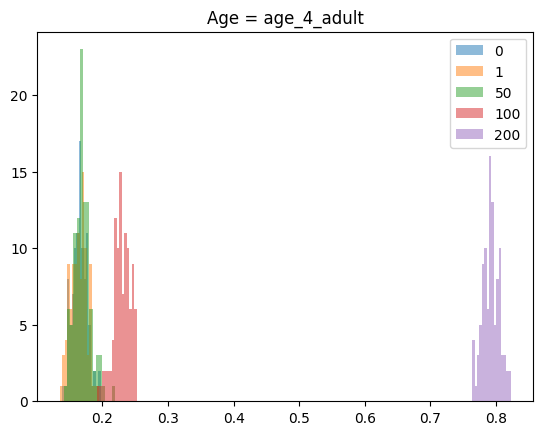

In [74]:
patient_chars = {
"Age": "age_4_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_1",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "True",
"Hypertension": "False",
}

plot_histograms_count_distrib(net2, patient_chars)

Optimal screening: No_screening
p_crc = 0.0008431446381633401
K = 0, mean_p_scr = 0.00023000000000000003, median_p_scr = 0.0
K = 1, mean_p_scr = 0.00016, median_p_scr = 0.0
K = 50, mean_p_scr = 0.00024, median_p_scr = 0.0
K = 100, mean_p_scr = 0.00017999999999999998, median_p_scr = 0.0
K = 200, mean_p_scr = 0.0002, median_p_scr = 0.0


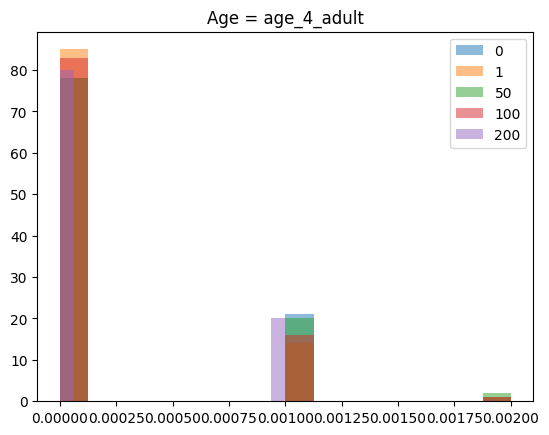

In [48]:
patient_chars = {
"Age": "age_4_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_2",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "False",
"Hypertension": "False",
}

plot_histograms_count_distrib(net2, patient_chars)